In [2]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# ============================================================
# STEP 2: Load Datasets
# ============================================================
fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")
aum = pd.read_csv("03_aum_by_fund_house.csv")
sip = pd.read_csv("04_monthly_sip_inflows.csv")
category = pd.read_csv("05_category_inflows.csv")
folios = pd.read_csv("06_industry_folio_count.csv")
performance = pd.read_csv("07_scheme_performance.csv")
transactions = pd.read_csv("08_investor_transactions.csv")
portfolio = pd.read_csv("09_portfolio_holdings.csv")
benchmark = pd.read_csv("10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [4]:
# ============================================================
# STEP 3: Dataset Summary
# ============================================================

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category Inflows": category,
    "Folio Count": folios,
    "Scheme Performance": performance,
    "Investor Transactions": transactions,
    "Portfolio Holdings": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():

    print("=" * 60)
    print(name)

    print("Rows :", df.shape[0])
    print("Columns :", df.shape[1])

Fund Master
Rows : 40
Columns : 15
NAV History
Rows : 46000
Columns : 3
AUM
Rows : 90
Columns : 5
SIP
Rows : 48
Columns : 6
Category Inflows
Rows : 144
Columns : 3
Folio Count
Rows : 21
Columns : 6
Scheme Performance
Rows : 40
Columns : 19
Investor Transactions
Rows : 32778
Columns : 13
Portfolio Holdings
Rows : 322
Columns : 8
Benchmark
Rows : 8050
Columns : 3


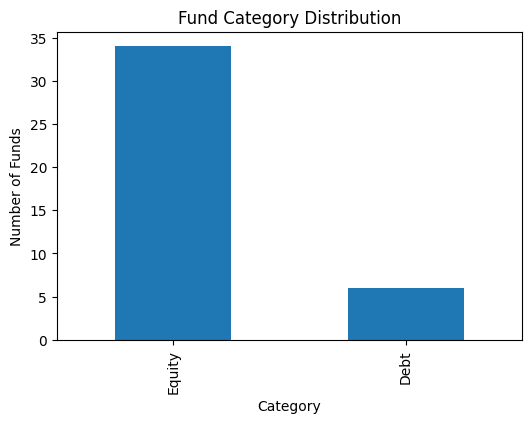

In [5]:
# ============================================================
# Analysis 1 : Fund Category Distribution
# ============================================================

category_count = fund_master["category"].value_counts()

plt.figure(figsize=(6,4))

category_count.plot(kind="bar")

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Funds")

plt.show()

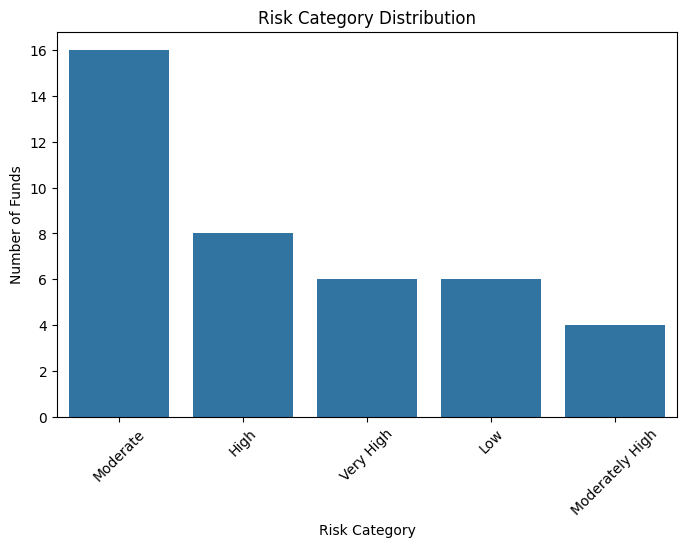

In [6]:
# ============================================================
# Analysis 2 : Risk Category Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category",
    order=fund_master["risk_category"].value_counts().index
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")

plt.xticks(rotation=45)

plt.show()


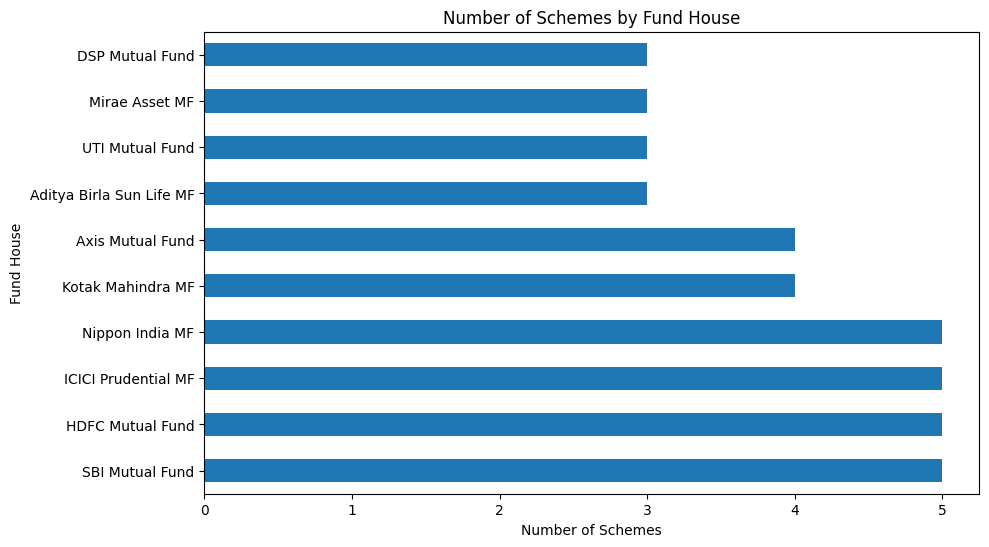

In [7]:
# ============================================================
# Analysis 3 : Fund House Distribution
# ============================================================

fund_house_count = fund_master["fund_house"].value_counts()

plt.figure(figsize=(10,6))

fund_house_count.plot(kind="barh")

plt.title("Number of Schemes by Fund House")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")

plt.show()

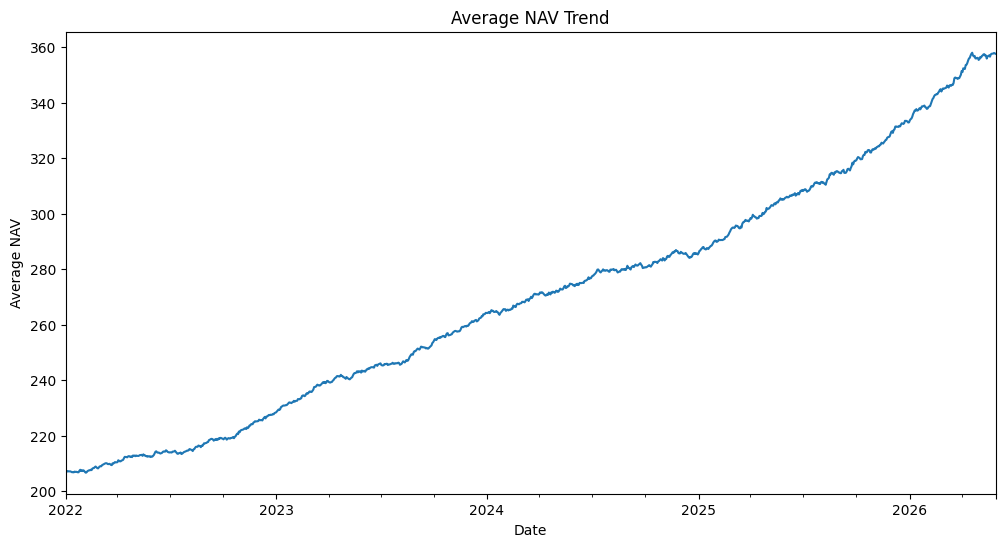

In [8]:
# ============================================================
# Analysis 4 : Average NAV Trend
# ============================================================
# Convert date column into datetime format

nav_history["date"] = pd.to_datetime(nav_history["date"])

# Calculate average NAV for each date

average_nav = (
    nav_history
    .groupby("date")["nav"]
    .mean()
)

plt.figure(figsize=(12,6))

average_nav.plot()

plt.title("Average NAV Trend")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.show()

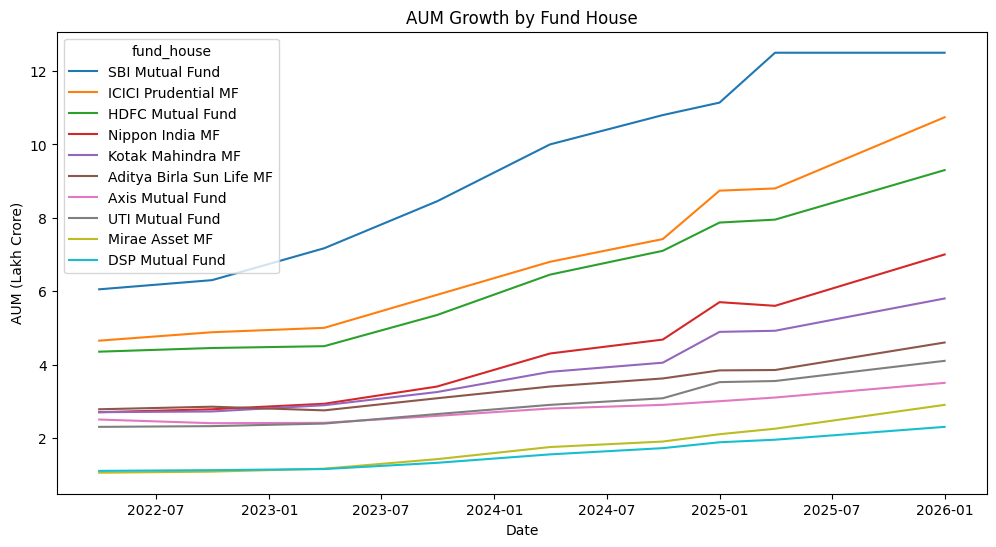

In [9]:
# ============================================================
# Analysis 5 : AUM Growth Trend
# ============================================================

aum["date"] = pd.to_datetime(aum["date"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Date")
plt.ylabel("AUM (Lakh Crore)")

plt.show()

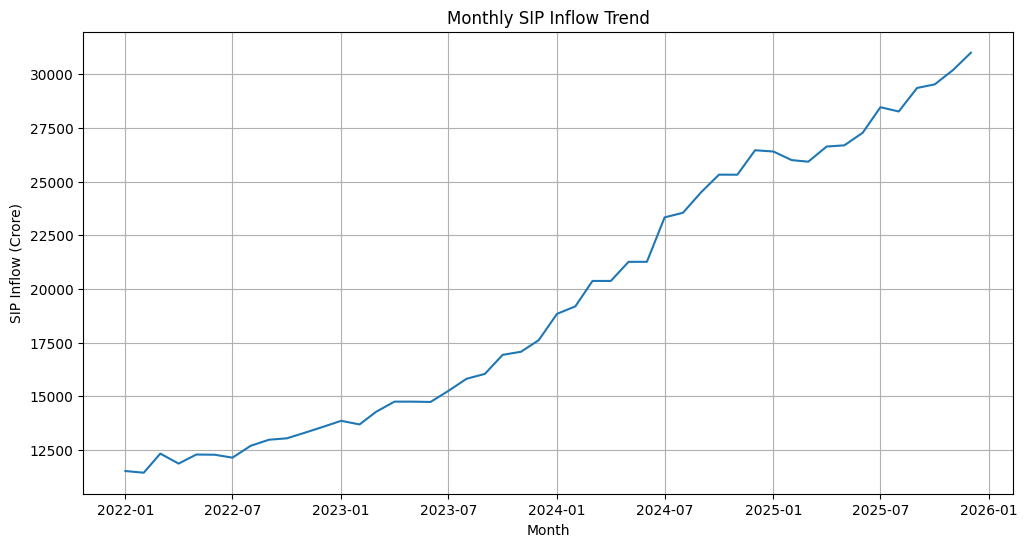

In [10]:
# ============================================================
# Analysis 6 : Monthly SIP Inflow Trend
# ============================================================

# Convert month column to datetime

sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.grid(True)

plt.show()


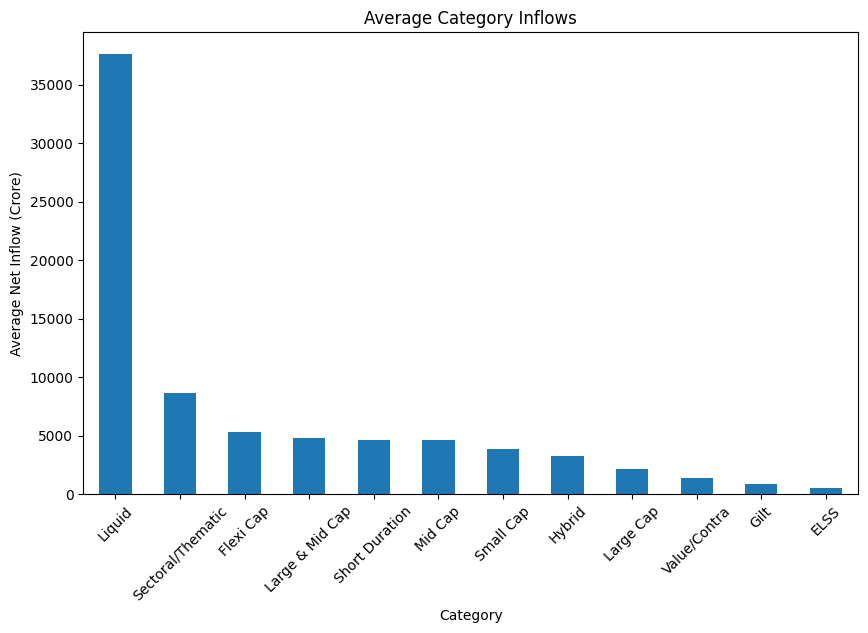

In [11]:
# ============================================================
# Analysis 7 : Category-wise Inflows
# ============================================================

category_avg = (
    category
    .groupby("category")["net_inflow_crore"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_avg.plot(kind="bar")

plt.title("Average Category Inflows")
plt.xlabel("Category")
plt.ylabel("Average Net Inflow (Crore)")

plt.xticks(rotation=45)

plt.show()

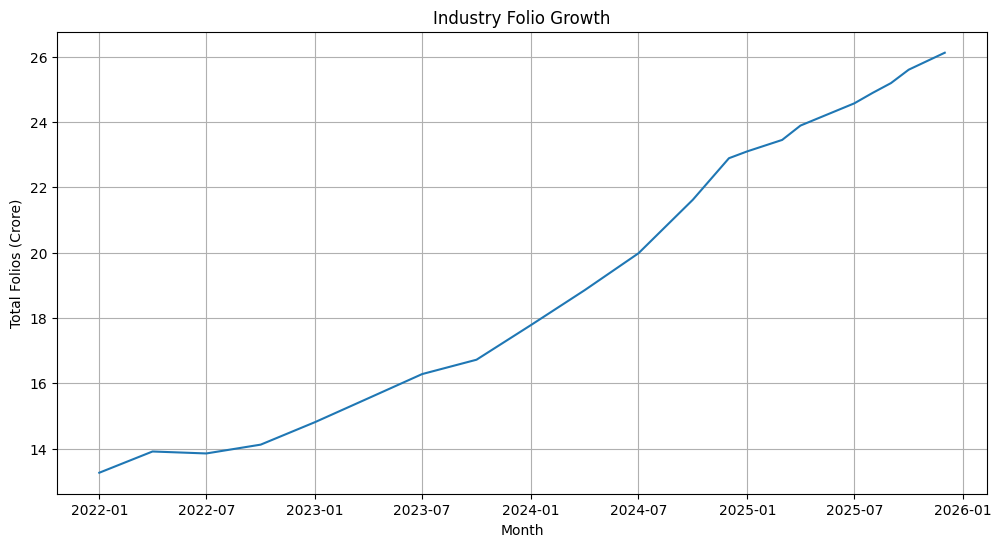

In [12]:
# ============================================================
# Analysis 8 : Industry Folio Growth
# ============================================================

folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

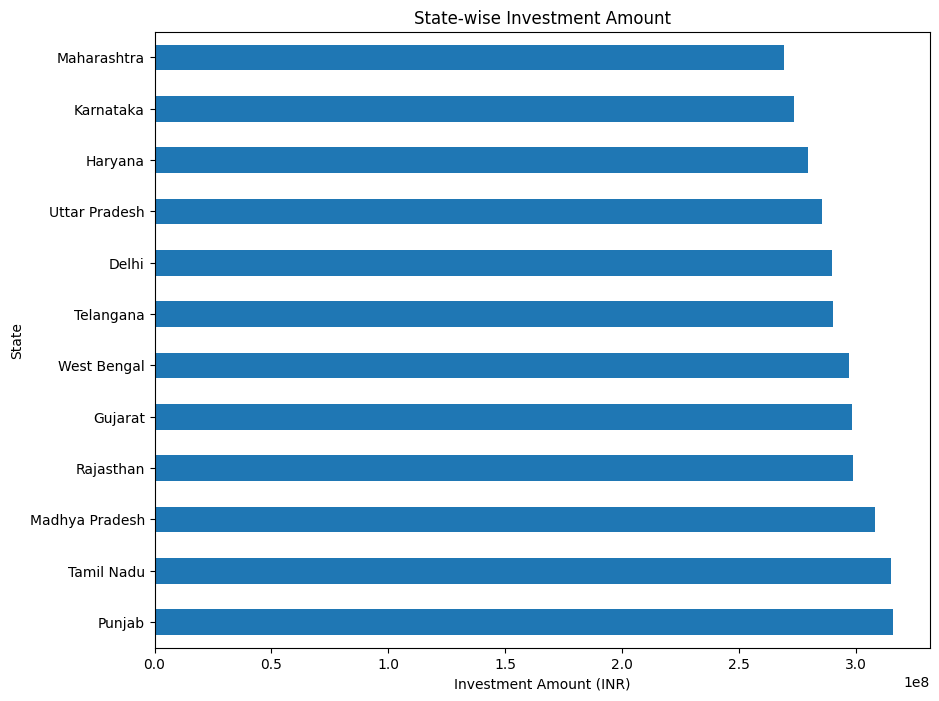

In [13]:
# ============================================================
# Analysis 9 : State-wise Investment
# ============================================================

state_investment = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

state_investment.plot(kind="barh")

plt.title("State-wise Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.show()

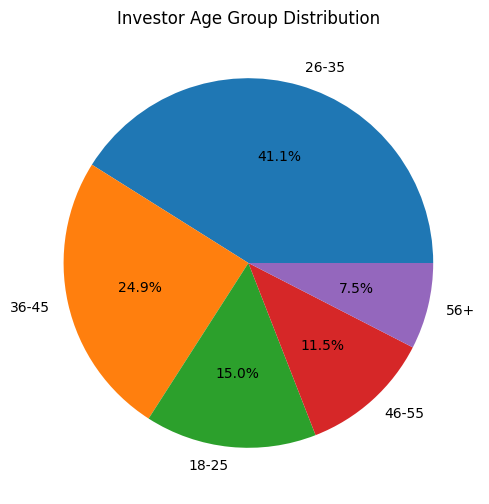

In [14]:
# ============================================================
# Analysis 10 : Age Group Distribution
# ============================================================

age_distribution = (
    transactions["age_group"]
    .value_counts()
)

plt.figure(figsize=(8,6))

age_distribution.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Investor Age Group Distribution")

plt.show()

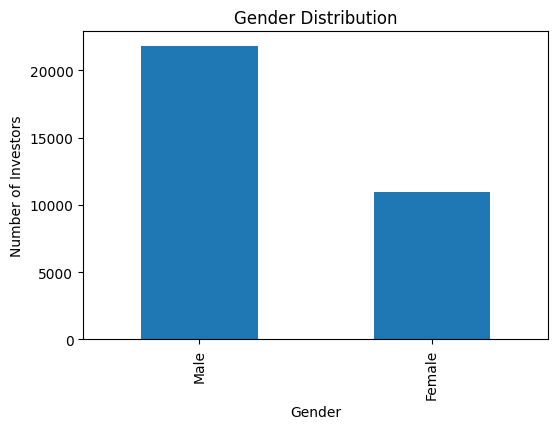

In [15]:
# ============================================================
# Analysis 11 : Gender Distribution
# ============================================================

gender_distribution = (
    transactions["gender"]
    .value_counts()
)

plt.figure(figsize=(6,4))

gender_distribution.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.show()

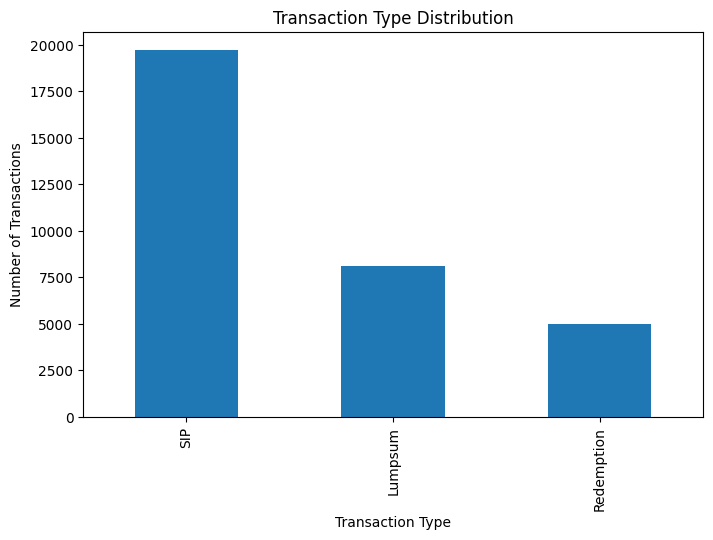

In [16]:
# ============================================================
# Analysis 12 : Transaction Type Distribution
# ============================================================

transaction_count = (
    transactions["transaction_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

transaction_count.plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

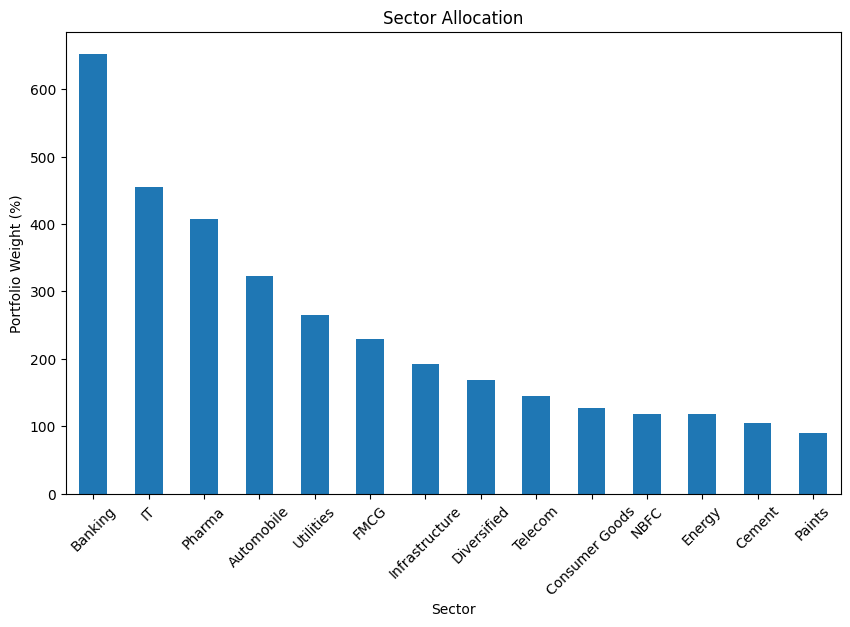

In [17]:
# ============================================================
# Analysis 13 : Sector Allocation
# ============================================================

sector_allocation = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sector_allocation.plot(kind="bar")

plt.title("Sector Allocation")
plt.xlabel("Sector")
plt.ylabel("Portfolio Weight (%)")

plt.xticks(rotation=45)

plt.show()

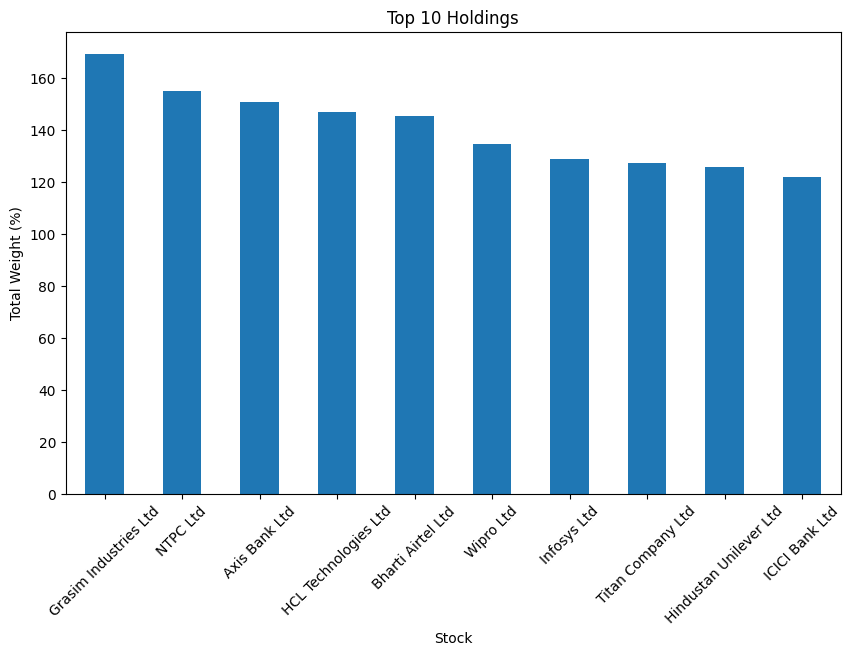

In [18]:
# ============================================================
# Analysis 14 : Top Holdings
# ============================================================

top_holdings = (
    portfolio
    .groupby("stock_name")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_holdings.plot(kind="bar")

plt.title("Top 10 Holdings")
plt.xlabel("Stock")
plt.ylabel("Total Weight (%)")

plt.xticks(rotation=45)

plt.show()

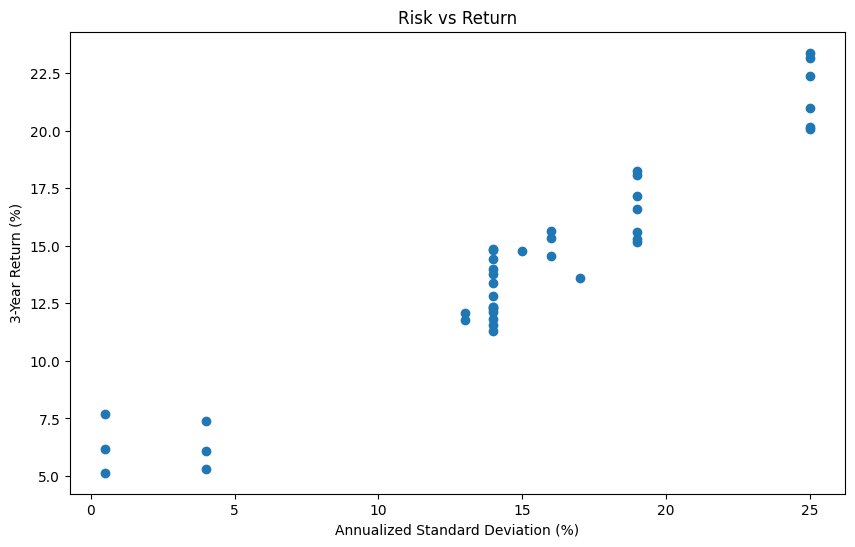

In [19]:
# ============================================================
# Analysis 15 : Risk vs Return
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"]
)

plt.title("Risk vs Return")
plt.xlabel("Annualized Standard Deviation (%)")
plt.ylabel("3-Year Return (%)")

plt.show()

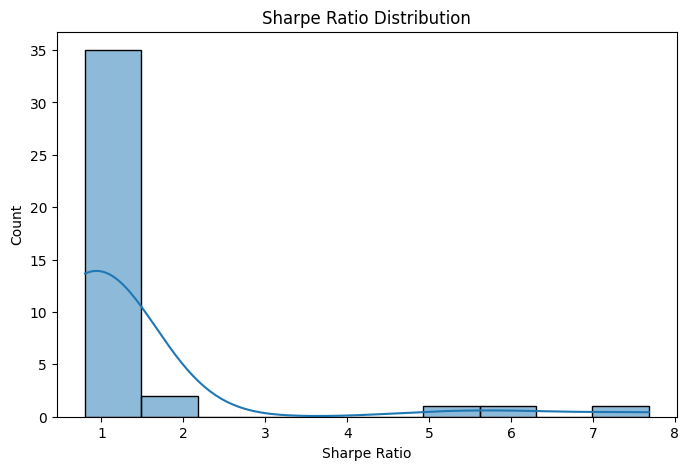

In [20]:
# ============================================================
# Analysis 16 : Sharpe Ratio Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    performance["sharpe_ratio"],
    bins=10,
    kde=True
)

plt.title("Sharpe Ratio Distribution")
plt.xlabel("Sharpe Ratio")

plt.show()

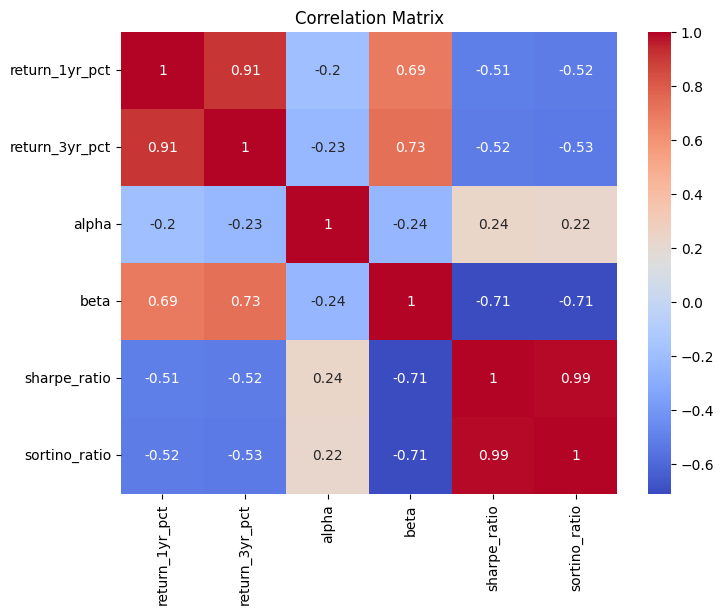

In [21]:
# ============================================================
# Analysis 17 : Correlation Matrix
# ============================================================

corr_columns = [
    "return_1yr_pct",
    "return_3yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio"
]

correlation_matrix = (
    performance[corr_columns]
    .corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()